# Gaze Analysis

## Step 1: View log files

In [22]:
import os
os.environ['PYTHONHASHSEED'] = '0'

# Force garbage collection
import gc
gc.collect()

print("Memory optimizations enabled")

Memory optimizations enabled


In [23]:
import pandas as pd
import os
from pathlib import Path

# Set up paths
logs_dir = Path('./Dot following 120 fps videos/Logs')
log_files = sorted(logs_dir.glob('*.xlsx'))

print(f"Found {len(log_files)} log files:")
for file in log_files:
    print(f"  - {file.name}")

Found 12 log files:
  - Participant 10_EK slow_Analysis 1_video_20260305_111050_detailed.xlsx
  - Participant 11_BD fast_Analysis 1_video_20260305_111116_detailed.xlsx
  - Participant 12_BD slow_Analysis 1_video_20260305_111142_detailed.xlsx
  - Participant 1_AM slow_Analysis 1_video_20260305_110700_detailed.xlsx
  - Participant 2_AM fast_Analysis 1_video_20260305_110725_detailed.xlsx
  - Participant 3_MTK fast_Analysis 1_video_20260305_110752_detailed.xlsx
  - Participant 4_MTK slow_Analysis 1_video_20260305_110817_detailed.xlsx
  - Participant 5_AM-2 fast_Analysis 1_video_20260305_110843_detailed.xlsx
  - Participant 6_AM-2 slow_Analysis 1_video_20260305_110906_detailed.xlsx
  - Participant 7_MTK-2 fast_Analysis 1_video_20260305_110931_detailed.xlsx
  - Participant 8_MTK-2 slow_Analysis 1_video_20260305_110958_detailed.xlsx
  - Participant 9_EK fast_Analysis 1_video_20260305_111024_detailed.xlsx


## Step 2: Remove headers and concatenate data

In [24]:
## Data Preview
# Load all dataframes into a dictionary
dataframes = {}

for file in log_files:
    raw = pd.read_excel(file, header=None)

    # Find row where first column equals "Video Time"
    header_row = raw[raw.iloc[:,0] == "Video Time"].index[0]

    df = pd.read_excel(file, skiprows=header_row)
    df = df.dropna(axis=1, how="all")

    key = file.stem
    dataframes[key] = df

    print(f"\n{key}")
    print(f"Shape: {df.shape}")
    print(df.head(2))


Participant 10_EK slow_Analysis 1_video_20260305_111050_detailed
Shape: (7288, 54)
     Video Time   Neutral     Happy       Sad     Angry  Surprised    Scared  \
0  00:00:00.000  0.421387  0.013535  0.136963  0.026917   0.000247  0.380859   
1  00:00:00.008  0.427698  0.013910  0.136505  0.027189   0.000256  0.377699   

   Disgusted  Contempt   Valence  ...  Sad from Voice Angry from Voice  \
0   0.017105  0.000109 -0.367325  ...         UNKNOWN          UNKNOWN   
1   0.016755  0.000110 -0.363790  ...         UNKNOWN          UNKNOWN   

  Valence from Voice Arousal from Voice  Loudness  Speech rate  \
0            UNKNOWN            UNKNOWN   UNKNOWN      UNKNOWN   
1            UNKNOWN            UNKNOWN   UNKNOWN      UNKNOWN   

                      Gaze type Gaze Location X Gaze Location Y  \
0  Unknown (Fixation / Saccade)         UNKNOWN         UNKNOWN   
1                       Saccade         UNKNOWN         UNKNOWN   

   Fixation Index  
0         UNKNOWN  
1         U

In [25]:
# Create individual dataframe variables for easy access
import re

for key, df in dataframes.items():
    # Remove trailing pattern like "1_video_20260305_110817_detailed"
    cleaned_key = re.sub(r'\s+\d+_video_\d{8}_\d{6}_\w+$', '', key)
    var_name = cleaned_key.replace(' ', '_').replace('-', '_')
    globals()[var_name] = df

# Display available dataframes
print("\nAvailable dataframes:")
for var in sorted(globals().keys()):
    if isinstance(globals()[var], pd.DataFrame):
        print(f"  - {var}")


Available dataframes:
  - Participant_10_EK_slow_Analysis
  - Participant_11_BD_fast_Analysis
  - Participant_12_BD_slow_Analysis
  - Participant_1_AM_slow_Analysis
  - Participant_2_AM_fast_Analysis
  - Participant_3_MTK_fast_Analysis
  - Participant_4_MTK_slow_Analysis
  - Participant_5_AM_2_fast_Analysis
  - Participant_6_AM_2_slow_Analysis
  - Participant_7_MTK_2_fast_Analysis
  - Participant_8_MTK_2_slow_Analysis
  - Participant_9_EK_fast_Analysis
  - df
  - df_clean
  - first_df
  - master_df
  - raw
  - summary_df
  - temp_df


In [26]:
# Preview first dataframe
first_df = list(dataframes.values())[0]
print("Sample of first dataframe:")
print(first_df.head())
print(f"\nData types:\n{first_df.dtypes}")

Sample of first dataframe:
     Video Time   Neutral     Happy       Sad     Angry  Surprised    Scared  \
0  00:00:00.000  0.421387  0.013535  0.136963  0.026917   0.000247  0.380859   
1  00:00:00.008  0.427698  0.013910  0.136505  0.027189   0.000256  0.377699   
2  00:00:00.016  0.434511  0.014283  0.137329  0.027417   0.000275  0.373771   
3  00:00:00.025  0.440999  0.014482  0.137841  0.027555   0.000301  0.370894   
4  00:00:00.033  0.446384  0.014384  0.138487  0.027595   0.000310  0.369454   

   Disgusted  Contempt   Valence  ...  Sad from Voice Angry from Voice  \
0   0.017105  0.000109 -0.367325  ...         UNKNOWN          UNKNOWN   
1   0.016755  0.000110 -0.363790  ...         UNKNOWN          UNKNOWN   
2   0.016431  0.000110 -0.359489  ...         UNKNOWN          UNKNOWN   
3   0.016081  0.000110 -0.356412  ...         UNKNOWN          UNKNOWN   
4   0.015791  0.000109 -0.355070  ...         UNKNOWN          UNKNOWN   

  Valence from Voice Arousal from Voice  Loudne

In [ ]:
import pandas as pd
import numpy as np

# Assuming 'dataframes' dictionary is already populated using your code

cleaned_dataframes = {}

missing_values = ["UNKNOWN", "FIT_FAILED", "FIND_FAILED", "untracked"]

for key, df in dataframes.items():
    # Make a copy to avoid SettingWithCopy warnings
    df_clean = df.copy()
    
    # Replace known missing value strings with NaN
    df_clean.replace(missing_values, np.nan, inplace=True)
    
    # Columns to keep as strings/objects (metadata)
    meta_cols = ['Video Time', 'Gender', 'Age', 'Glasses', 'Gaze type', 'Participant Name', 'Stimulus', 'Event Marker']
    
    # Convert all other columns to numeric
    for col in df_clean.columns:
        if col not in meta_cols:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            
    # Optional: Convert 'Video Time' to a timedelta or datetime object for time-series plotting
    df_clean['Video Time'] = pd.to_timedelta(df_clean['Video Time'], errors='coerce')
    
    cleaned_dataframes[key] = df_clean
    
    print(f"{key} successfully cleaned!")

Participant 10_EK slow_Analysis 1_video_20260305_111050_detailed successfully cleaned!
Participant 11_BD fast_Analysis 1_video_20260305_111116_detailed successfully cleaned!
Participant 12_BD slow_Analysis 1_video_20260305_111142_detailed successfully cleaned!
Participant 1_AM slow_Analysis 1_video_20260305_110700_detailed successfully cleaned!
Participant 2_AM fast_Analysis 1_video_20260305_110725_detailed successfully cleaned!
Participant 3_MTK fast_Analysis 1_video_20260305_110752_detailed successfully cleaned!
Participant 4_MTK slow_Analysis 1_video_20260305_110817_detailed successfully cleaned!
Participant 5_AM-2 fast_Analysis 1_video_20260305_110843_detailed successfully cleaned!
Participant 6_AM-2 slow_Analysis 1_video_20260305_110906_detailed successfully cleaned!
Participant 7_MTK-2 fast_Analysis 1_video_20260305_110931_detailed successfully cleaned!
Participant 8_MTK-2 slow_Analysis 1_video_20260305_110958_detailed successfully cleaned!
Participant 9_EK fast_Analysis 1_video_

In [36]:
import pandas as pd
import numpy as np

def inspect_dataframe_columns(df):
    """
    Inspects each column to find the percentage of missing/null values
    and prints either numeric metrics or unique string values.
    """
    
    missing_indicators = ["UNKNOWN", "FIT_FAILED", "FIND_FAILED", "untracked"]
    
    # Work on a copy so we don't accidentally mutate the original data
    temp_df = df.replace(missing_indicators, np.nan)
    total_rows = len(temp_df)
    
    summary_data = []
    
    for col in temp_df.columns:
        # 1. Calculate the percentage of missing values
        null_count = temp_df[col].isna().sum()
        null_pct = (null_count / total_rows) * 100
        
        # 2. Try to convert to numeric using 'coerce'
        numeric_series = pd.to_numeric(temp_df[col], errors='coerce')
        
        # 3. Determine if the column is actually numeric
        # If coercing to numeric didn't create any NEW nulls, it's a numeric column
        is_numeric = (numeric_series.notna().sum() == temp_df[col].notna().sum()) and (temp_df[col].notna().sum() > 0)
        
        if is_numeric:
            metrics = f"Min: {numeric_series.min():.3f} | Max: {numeric_series.max():.3f} | Mean: {numeric_series.mean():.3f}"
        else:
            # It's a categorical / string column
            if null_count == total_rows:
                metrics = "All Null"
            else:
                unique_vals = temp_df[col].dropna().unique()
                if len(unique_vals) <= 5:
                    metrics = f"Unique ({len(unique_vals)}): {list(unique_vals)}"
                else:
                    metrics = f"Unique ({len(unique_vals)}): {list(unique_vals[:5])}..."
                    
        summary_data.append({
            "Column": col,
            "Null %": f"{null_pct:.1f}%",
            "Metrics": metrics
        })
        
    # Return as a formatted DataFrame for easy viewing
    return pd.DataFrame(summary_data)


# Run the inspection on the first dataframe in your dictionary
first_key = list(cleaned_dataframes.keys())[0]
print(f"--- Column Inspection for: {first_key} ---")

summary_df = inspect_dataframe_columns(cleaned_dataframes[first_key])

# Increase pandas display limits so you can see all 55 rows
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

print(summary_df)

--- Column Inspection for: Participant 10_EK slow_Analysis 1_video_20260305_111050_detailed ---
                            Column  Null %  \
0                       Video Time    0.0%   
1                          Neutral    0.0%   
2                            Happy    0.0%   
3                              Sad    0.0%   
4                            Angry    0.0%   
5                        Surprised    0.0%   
6                           Scared    0.0%   
7                        Disgusted    0.0%   
8                         Contempt    0.0%   
9                          Valence    0.0%   
10                         Arousal    0.0%   
11                          Gender    0.0%   
12                             Age    0.0%   
13                         Glasses    0.0%   
14                           Pitch    0.0%   
15                             Yaw    0.0%   
16                            Roll    0.0%   
17                       Landmarks  100.0%   
18                    3d Landm

In [41]:
# Select only the columns of interest
columns_of_interest = [
    'Horizontal gaze angle',
    'Vertical gaze angle',
    'Gaze Location X',
    'Gaze Location Y',
    'Gaze type',
    'Fixation Index',
    'Horizontal position',
    'Vertical position',
    'Depth position',
    'Participant Name',
    'Video Time'
]

# Filter each dataframe to keep only these columns
filtered_dataframes = {}
for key, df in cleaned_dataframes.items():
    # Keep only columns that exist in the dataframe
    available_cols = [col for col in columns_of_interest if col in df.columns]
    filtered_dataframes[key] = df[available_cols]

# Run inspection on filtered dataframes
first_key = list(filtered_dataframes.keys())[4]
print(f"--- Column Inspection for: {first_key} ---")

summary_df = inspect_dataframe_columns(filtered_dataframes[first_key])

print(summary_df)

--- Column Inspection for: Participant 2_AM fast_Analysis 1_video_20260305_110725_detailed ---
                   Column  Null %  \
0   Horizontal gaze angle   33.1%   
1     Vertical gaze angle   33.1%   
2         Gaze Location X  100.0%   
3         Gaze Location Y  100.0%   
4               Gaze type   33.1%   
5          Fixation Index  100.0%   
6     Horizontal position    0.0%   
7       Vertical position    0.0%   
8          Depth position    0.0%   
9        Participant Name    0.0%   
10             Video Time    0.0%   

                                                    Metrics  
0                Min: -36.923 | Max: 16.160 | Mean: -14.478  
1                Min: -19.614 | Max: -7.397 | Mean: -14.450  
2                                                  All Null  
3                                                  All Null  
4   Unique (2): ['Unknown (Fixation / Saccade)', 'Saccade']  
5                                                  All Null  
6              Min: -109.7

In [42]:
# Check row counts for all final dataframes
print("Row counts for final_dataframes:")
for key, df in filtered_dataframes.items():
    print(f"{key}: {len(df)} rows")

# Ensure all final dataframes have exactly 7200 rows
print("\nTrimming all dataframes to 7200 rows...")
for key in filtered_dataframes:
    original_count = len(filtered_dataframes[key])
    filtered_dataframes[key] = filtered_dataframes[key].iloc[:7200]
    new_count = len(filtered_dataframes[key])
    print(f"{key}: {original_count} → {new_count} rows")

print("\nFinal row counts after trimming:")
for key, df in filtered_dataframes.items():
    print(f"{key}: {len(df)} rows")


Row counts for final_dataframes:
Participant 10_EK slow_Analysis 1_video_20260305_111050_detailed: 7288 rows
Participant 11_BD fast_Analysis 1_video_20260305_111116_detailed: 7346 rows
Participant 12_BD slow_Analysis 1_video_20260305_111142_detailed: 7730 rows
Participant 1_AM slow_Analysis 1_video_20260305_110700_detailed: 7528 rows
Participant 2_AM fast_Analysis 1_video_20260305_110725_detailed: 7267 rows
Participant 3_MTK fast_Analysis 1_video_20260305_110752_detailed: 7337 rows
Participant 4_MTK slow_Analysis 1_video_20260305_110817_detailed: 7358 rows
Participant 5_AM-2 fast_Analysis 1_video_20260305_110843_detailed: 7265 rows
Participant 6_AM-2 slow_Analysis 1_video_20260305_110906_detailed: 7296 rows
Participant 7_MTK-2 fast_Analysis 1_video_20260305_110931_detailed: 7337 rows
Participant 8_MTK-2 slow_Analysis 1_video_20260305_110958_detailed: 7545 rows
Participant 9_EK fast_Analysis 1_video_20260305_111024_detailed: 7296 rows

Trimming all dataframes to 7200 rows...
Participant

In [43]:
import pandas as pd

master_list = []

for key, df in filtered_dataframes.items():
    # Work on a copy
    temp_df = df.copy()
    
    # 1. Extract condition data from the filename (the 'key')
    # Example key: "Participant 1_AM slow_Analysis 1_video_20260227_104338_detailed"
    parts = key.split('_')
    
    # Participant ID (e.g., "Participant 1")
    temp_df['Participant'] = parts[0]
    
    # Condition string (e.g., "AM slow")
    condition_str = parts[1] 
    
    # Split into Type (AM/MTK) and Speed (slow/fast)
    temp_df['Type'] = condition_str.split(' ')[0]
    temp_df['Speed'] = condition_str.split(' ')[1]
    
    # 2. Convert 'Video Time' from a string format (HH:MM:SS.ms) to total seconds
    # This makes time-series plotting much easier
    temp_df['Time_Seconds'] = pd.to_timedelta(temp_df['Video Time']).dt.total_seconds()
    
    # 3. Append to our list
    master_list.append(temp_df)

# 4. Concatenate all dataframes into one
master_df = pd.concat(master_list, ignore_index=True)

print(f"Master DataFrame created! Shape: {master_df.shape}")
print(master_df[['Participant', 'Type', 'Speed', 'Time_Seconds']].head())

Master DataFrame created! Shape: (86400, 15)
      Participant Type Speed  Time_Seconds
0  Participant 10   EK  slow         0.000
1  Participant 10   EK  slow         0.008
2  Participant 10   EK  slow         0.016
3  Participant 10   EK  slow         0.025
4  Participant 10   EK  slow         0.033


In [44]:
# Display unique values of the new columns
print("Unique values in new columns:\n")

print("Participant:")
print(sorted(master_df['Participant'].unique()))
print(f"Count: {master_df['Participant'].nunique()}\n")

print("Type:")
print(sorted(master_df['Type'].unique()))
print(f"Count: {master_df['Type'].nunique()}\n")

print("Speed:")
print(sorted(master_df['Speed'].unique()))
print(f"Count: {master_df['Speed'].nunique()}\n")

print("Time_Seconds stats:")
print(f"Min: {master_df['Time_Seconds'].min():.2f}")
print(f"Max: {master_df['Time_Seconds'].max():.2f}")
print(f"Mean: {master_df['Time_Seconds'].mean():.2f}")

Unique values in new columns:

Participant:
['Participant 1', 'Participant 10', 'Participant 11', 'Participant 12', 'Participant 2', 'Participant 3', 'Participant 4', 'Participant 5', 'Participant 6', 'Participant 7', 'Participant 8', 'Participant 9']
Count: 12

Type:
['AM', 'AM-2', 'BD', 'EK', 'MTK', 'MTK-2']
Count: 6

Speed:
['fast', 'slow']
Count: 2

Time_Seconds stats:
Min: 0.00
Max: 59.99
Mean: 30.00


In [46]:
# Replace "Unknown" with "saccade" in Gaze type column if it exists
if 'Gaze type' in master_df.columns:
    before_count = (master_df['Gaze type'] == 'Unknown (Fixation / Saccade)').sum()
    master_df['Gaze type'] = master_df['Gaze type'].replace('Unknown (Fixation / Saccade)', 'Saccade')
    after_count = (master_df['Gaze type'] == 'Saccade').sum()
    print(f"Replaced {before_count} 'Unknown' values with 'Saccade' in Gaze type column")
    print(f"\nUpdated Gaze type unique values:")
    print(master_df['Gaze type'].unique())
else:
    print("'Gaze type' column not found in master_df")

Replaced 64 'Unknown' values with 'Saccade' in Gaze type column

Updated Gaze type unique values:
<StringArray>
['Saccade', 'Fixation', nan]
Length: 3, dtype: str


In [47]:
master_df.columns

Index(['Horizontal gaze angle', 'Vertical gaze angle', 'Gaze Location X',
       'Gaze Location Y', 'Gaze type', 'Fixation Index', 'Horizontal position',
       'Vertical position', 'Depth position', 'Participant Name', 'Video Time',
       'Participant', 'Type', 'Speed', 'Time_Seconds'],
      dtype='str')

In [48]:
summary_df = inspect_dataframe_columns(master_df)

print(summary_df)

                   Column  Null %  \
0   Horizontal gaze angle    7.8%   
1     Vertical gaze angle    7.8%   
2         Gaze Location X  100.0%   
3         Gaze Location Y  100.0%   
4               Gaze type    7.8%   
5          Fixation Index   98.2%   
6     Horizontal position    0.1%   
7       Vertical position    0.1%   
8          Depth position    0.1%   
9        Participant Name    0.0%   
10             Video Time    0.0%   
11            Participant    0.0%   
12                   Type    0.0%   
13                  Speed    0.0%   
14           Time_Seconds    0.0%   

                                                                                                     Metrics  
0                                                                  Min: -36.923 | Max: 32.093 | Mean: -3.391  
1                                                                 Min: -26.906 | Max: 19.454 | Mean: -11.147  
2                                                                         

In [49]:
import pandas as pd
import numpy as np
import os

# 1. Sort the dataframe chronologically for each participant to ensure accurate math
master_df = master_df.sort_values(by=['Participant', 'Time_Seconds']).reset_index(drop=True)

# 2. Clean the 'Type' column (e.g., changing 'AM-2' to 'AM')
# Since Participant 5 and Participant 6 are just 'AM' doing a second experiment
master_df['Clean_Type'] = master_df['Type'].str.replace('-2', '')

# 3. Calculate Angular Distance (Degrees) between consecutive 8ms frames
# We use the Pythagorean theorem on the horizontal and vertical gaze angles
master_df['Delta_Horiz_Angle'] = master_df.groupby('Participant')['Horizontal gaze angle'].diff()
master_df['Delta_Vert_Angle'] = master_df.groupby('Participant')['Vertical gaze angle'].diff()

master_df['Gaze_Angle_Distance'] = np.sqrt(
    master_df['Delta_Horiz_Angle']**2 + 
    master_df['Delta_Vert_Angle']**2
)

# 4. Calculate Time Difference
# This should be roughly 0.008 seconds for your 120Hz/125Hz camera
master_df['Delta_Time'] = master_df.groupby('Participant')['Time_Seconds'].diff()

# 5. Calculate Angular Velocity (Degrees per Second)
# Speed = Distance / Time
master_df['Gaze_Angular_Velocity'] = master_df['Gaze_Angle_Distance'] / master_df['Delta_Time']

# 6. Create unique IDs for distinct Fixation and Saccade events
# This groups consecutive rows of the same 'Gaze type' together
master_df['Gaze_Event_ID'] = (master_df['Gaze type'] != master_df['Gaze type'].shift()).cumsum()

# 7. Save the fully processed Master DataFrame to a CSV
output_filename = "processed_master_eye_tracking.csv"
master_df.to_csv(output_filename, index=False)
print(f"Success! Processed data saved to: {os.path.abspath(output_filename)}")

# Quick preview of the new columns
print("\nPreview of Angular Derived Columns:")
print(master_df[['Participant', 'Time_Seconds', 'Gaze type', 'Gaze_Angle_Distance', 'Gaze_Angular_Velocity']].head())

Success! Processed data saved to: c:\Users\h703325073\Desktop\behavioral_lab\DrAnilMathur\Dot tracking\processed_master_eye_tracking.csv

Preview of Angular Derived Columns:
     Participant  Time_Seconds Gaze type  Gaze_Angle_Distance  \
0  Participant 1         0.000   Saccade                  NaN   
1  Participant 1         0.008   Saccade             0.803001   
2  Participant 1         0.016   Saccade             0.371127   
3  Participant 1         0.025   Saccade             0.309575   
4  Participant 1         0.033   Saccade             0.774514   

   Gaze_Angular_Velocity  
0                    NaN  
1             100.375136  
2              46.390905  
3              34.397204  
4              96.814256  


# Load the processed master dataframe

In [1]:
import os
os.environ['PYTHONHASHSEED'] = '0'

# Force garbage collection
import gc
gc.collect()

print("Memory optimizations enabled")

Memory optimizations enabled


In [9]:
import pandas as pd
master_df = pd.read_csv("processed_master_eye_tracking.csv")

--- Overall Gaze Event Summary ---
           Total_Angular_Distance  Peak_Velocity
Gaze type                                       
Fixation                     2.35          26.58
Saccade                     95.46         118.72


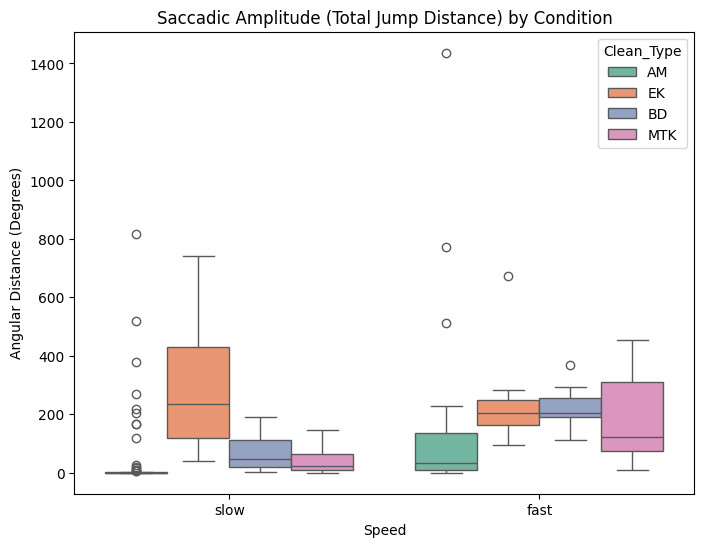

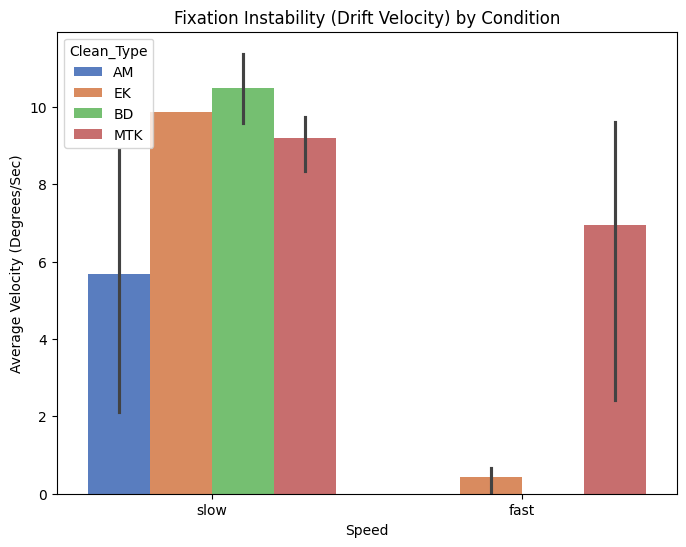

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# If you are starting fresh in a new notebook, uncomment the line below to load the data:
# master_df = pd.read_csv("processed_master_eye_tracking.csv")

# 1. Group by the Event ID to summarize each distinct Saccade or Fixation
gaze_events_summary = master_df.groupby(['Participant', 'Clean_Type', 'Speed', 'Gaze_Event_ID', 'Gaze type']).agg(
    Duration=('Time_Seconds', lambda x: x.max() - x.min()),
    Total_Angular_Distance=('Gaze_Angle_Distance', 'sum'),
    Peak_Velocity=('Gaze_Angular_Velocity', 'max'),
    Average_Velocity=('Gaze_Angular_Velocity', 'mean')
).reset_index()

# Filter out the "Unknown" starting rows
gaze_events_summary = gaze_events_summary[gaze_events_summary['Gaze type'].isin(['Fixation', 'Saccade'])]

print("--- Overall Gaze Event Summary ---")
print(gaze_events_summary.groupby('Gaze type')[['Total_Angular_Distance', 'Peak_Velocity']].mean().round(2))

# 2. Plot: Saccade Distance by Task Speed
# Did the "fast" task cause participants to make wider, more frantic eye jumps?
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=gaze_events_summary[gaze_events_summary['Gaze type'] == 'Saccade'], 
    x='Speed', 
    y='Total_Angular_Distance',
    hue='Clean_Type', # See if AM vs MTK vs EK layouts caused different jump distances
    palette='Set2'
)
plt.title('Saccadic Amplitude (Total Jump Distance) by Condition')
plt.ylabel('Angular Distance (Degrees)')
# Limit Y axis to remove massive outliers from blinks/tracking errors

plt.show()

# 3. Plot: Fixation Stability
# High velocity during a fixation means the eye was drifting/unstable
plt.figure(figsize=(8, 6))
sns.barplot(
    data=gaze_events_summary[gaze_events_summary['Gaze type'] == 'Fixation'], 
    x='Speed', 
    y='Average_Velocity',
    hue='Clean_Type',
    palette='muted'
)
plt.title('Fixation Instability (Drift Velocity) by Condition')
plt.ylabel('Average Velocity (Degrees/Sec)')
plt.show()

In [11]:
# Check the count of fixations specifically in the 'fast' condition
fast_fixations = master_df[(master_df['Speed'] == 'fast') & (master_df['Gaze type'] == 'Fixation')]

print("Fixation Counts in the 'Fast' Condition:")
print(fast_fixations.groupby('Clean_Type').size())

Fixation Counts in the 'Fast' Condition:
Clean_Type
EK     136
MTK    137
dtype: int64


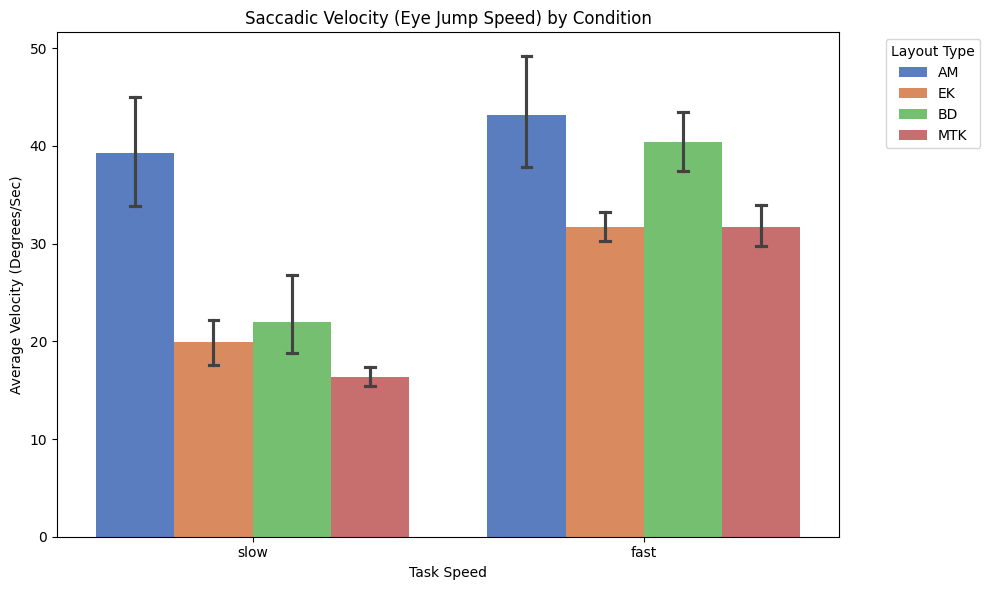

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plotting Average Velocity of Saccades instead of Fixations
sns.barplot(
    data=gaze_events_summary[gaze_events_summary['Gaze type'] == 'Saccade'], 
    x='Speed', 
    y='Average_Velocity',
    hue='Clean_Type',
    palette='muted',
    capsize=0.1 # Adds little caps to the error bars to make them easier to read
)

plt.title('Saccadic Velocity (Eye Jump Speed) by Condition')
plt.ylabel('Average Velocity (Degrees/Sec)')
plt.xlabel('Task Speed')

# Move the legend outside the plot so it doesn't cover any bars
plt.legend(title='Layout Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

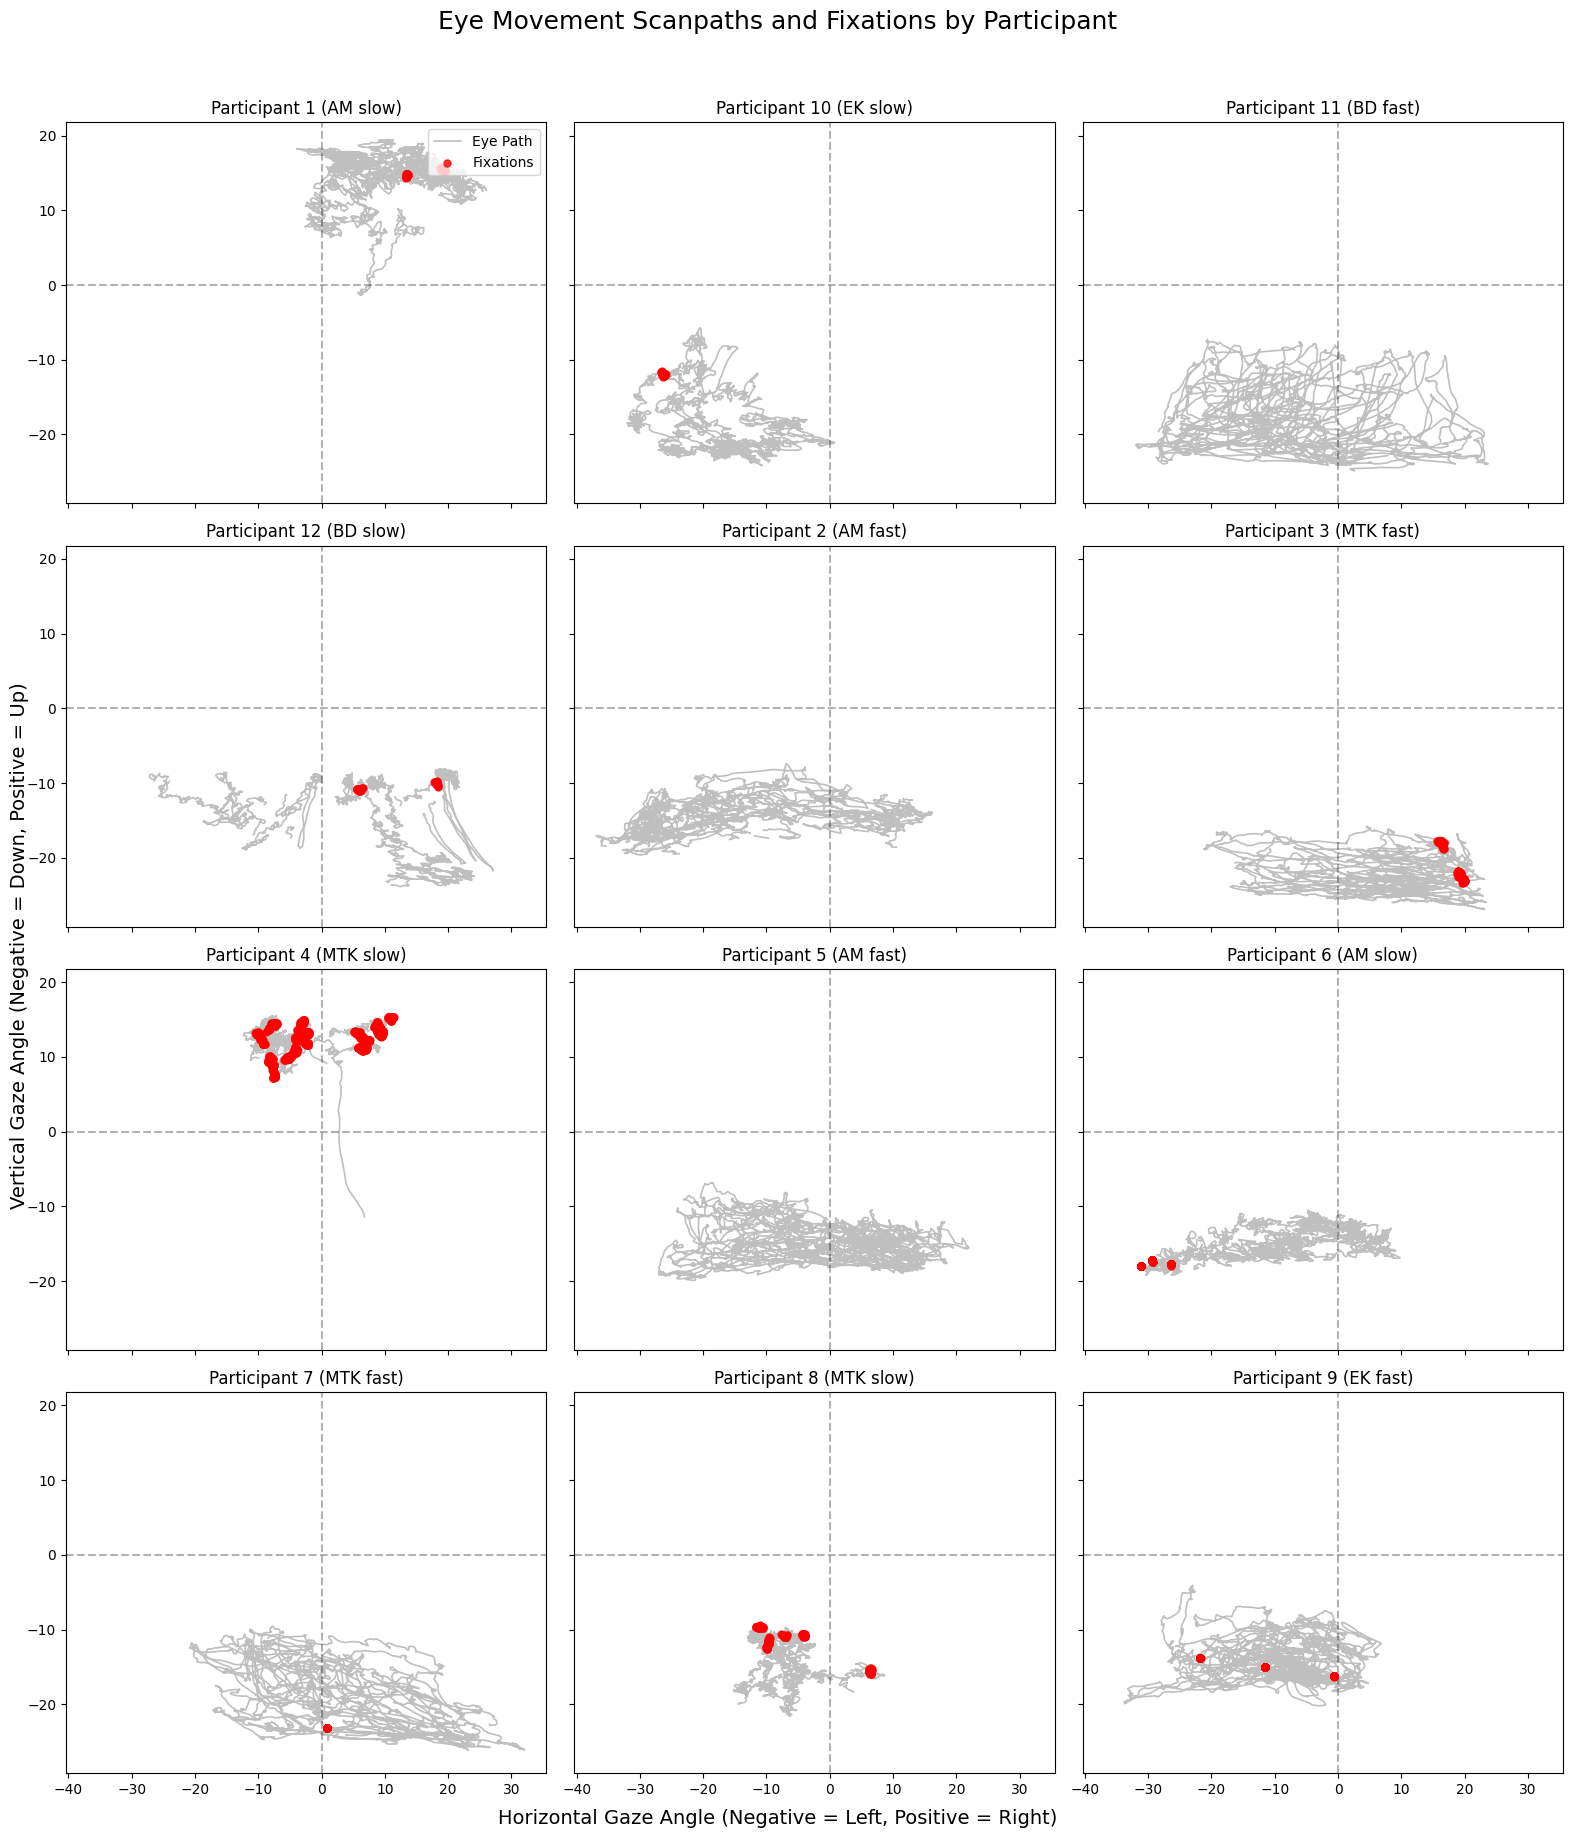

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get a list of the unique participants
participants = master_df['Participant'].unique()

# 2. Create a figure with a grid of subplots (4 rows, 3 columns = 12 plots)
fig, axes = plt.subplots(4, 3, figsize=(16, 18), sharex=True, sharey=True)
axes = axes.flatten() # Flatten the 4x3 grid into a 1D list so we can loop through it easily

for i, p in enumerate(participants):
    ax = axes[i]
    
    # Filter the data down to just this specific participant
    p_data = master_df[master_df['Participant'] == p].copy()
    
    # Extract their specific condition (e.g., "AM slow") for the title
    condition = f"{p_data['Clean_Type'].iloc[0]} {p_data['Speed'].iloc[0]}"
    
    # 3. Plot the continuous eye movement path (the Saccades and Drifts)
    ax.plot(
        p_data['Horizontal gaze angle'], 
        p_data['Vertical gaze angle'], 
        color='gray', 
        alpha=0.5, 
        linewidth=1.2,
        label='Eye Path'
    )
    
    # 4. Filter out ONLY the rows where the software detected a Fixation
    fixations = p_data[p_data['Gaze type'] == 'Fixation']
    
    # 5. Drop a distinct dot for every fixation 
    # (The 'if' statement prevents errors for participants who had 0 fixations in the 'fast' tasks)
    if not fixations.empty:
        ax.scatter(
            fixations['Horizontal gaze angle'], 
            fixations['Vertical gaze angle'], 
            color='red', 
            s=25,        # Size of the dot
            alpha=0.8,
            zorder=5,    # Forces the red dots to be drawn ON TOP of the gray lines
            label='Fixations'
        )
    
    # Add crosshairs to mark the dead-center of the screen
    ax.axhline(0, color='black', linestyle='--', alpha=0.3)
    ax.axvline(0, color='black', linestyle='--', alpha=0.3)
    
    # Title each subplot with the participant and their condition
    ax.set_title(f"{p} ({condition})")
    
    # Only add the legend to the very first plot so it doesn't clutter the whole grid
    if i == 0:
        ax.legend(loc='upper right')

# 6. Add master labels for the entire figure
fig.supxlabel('Horizontal Gaze Angle (Negative = Left, Positive = Right)', fontsize=14)
fig.supylabel('Vertical Gaze Angle (Negative = Down, Positive = Up)', fontsize=14)
fig.suptitle('Eye Movement Scanpaths and Fixations by Participant', fontsize=18, y=1.02)

# Adjust spacing so the titles don't overlap
plt.tight_layout()
plt.show()

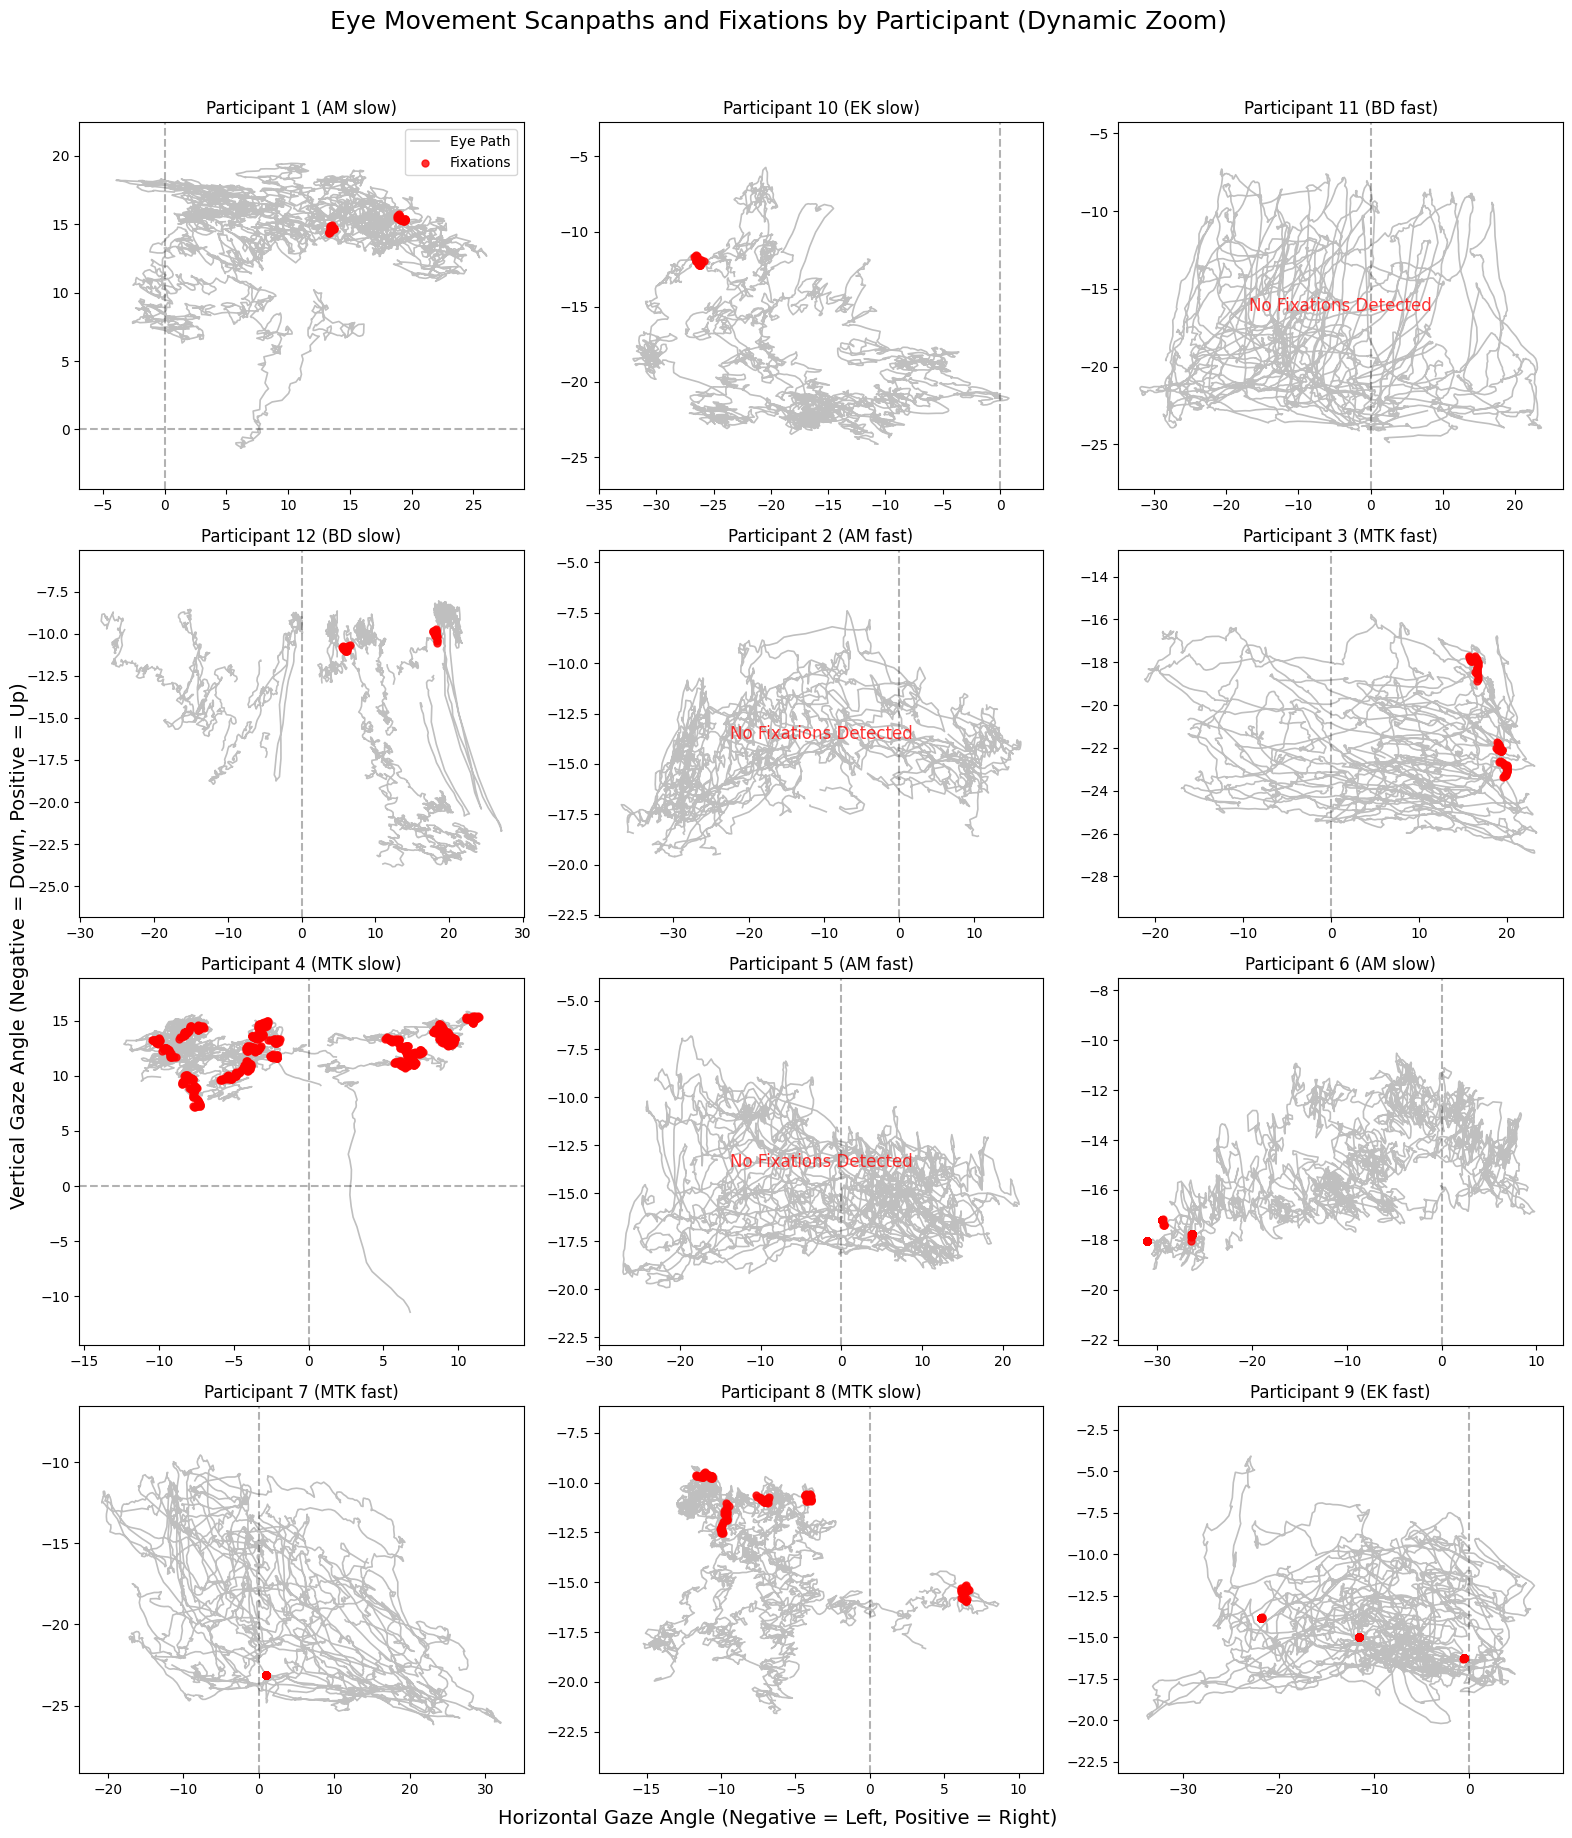

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get a list of the unique participants
participants = master_df['Participant'].unique()

# 2. Create a figure with a grid of subplots (Removed sharex and sharey for dynamic zoom)
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten() # Flatten the 4x3 grid into a 1D list so we can loop through it easily

for i, p in enumerate(participants):
    ax = axes[i]
    
    # Filter the data down to just this specific participant
    p_data = master_df[master_df['Participant'] == p].copy()
    
    # Extract their specific condition (e.g., "AM slow") for the title
    condition = f"{p_data['Clean_Type'].iloc[0]} {p_data['Speed'].iloc[0]}"
    
    # 3. Plot the continuous eye movement path (the Saccades and Drifts)
    ax.plot(
        p_data['Horizontal gaze angle'], 
        p_data['Vertical gaze angle'], 
        color='gray', 
        alpha=0.5, 
        linewidth=1.2,
        label='Eye Path'
    )
    
    # 4. Filter out ONLY the rows where the software detected a Fixation
    fixations = p_data[p_data['Gaze type'] == 'Fixation']
    
    # 5. Drop a distinct dot for every fixation 
    if not fixations.empty:
        ax.scatter(
            fixations['Horizontal gaze angle'], 
            fixations['Vertical gaze angle'], 
            color='red', 
            s=25,        # Size of the dot
            alpha=0.8,
            zorder=5,    # Forces the red dots to be drawn ON TOP of the gray lines
            label='Fixations'
        )
    else:
        # Add a note if they never stopped to fixate
        ax.text(0.5, 0.5, 'No Fixations Detected', 
                ha='center', va='center', color='red', alpha=0.8, fontsize=12,
                transform=ax.transAxes, zorder=10)
    
    # Add crosshairs to mark the dead-center of the screen
    ax.axhline(0, color='black', linestyle='--', alpha=0.3)
    ax.axvline(0, color='black', linestyle='--', alpha=0.3)
    
    # Title each subplot with the participant and their condition
    ax.set_title(f"{p} ({condition})")
    
    # Only add the legend to the very first plot so it doesn't clutter the whole grid
    if i == 0:
        ax.legend(loc='upper right')
        
    # --- DYNAMIC ZOOM LOGIC ---
    # Find the min and max coordinates for the ENTIRE eye path for this participant
    x_min, x_max = p_data['Horizontal gaze angle'].min(), p_data['Horizontal gaze angle'].max()
    y_min, y_max = p_data['Vertical gaze angle'].min(), p_data['Vertical gaze angle'].max()
    
    # Add a 3-degree padding so the lines don't hit the exact edge of the box
    padding = 3
    ax.set_xlim(x_min - padding, x_max + padding)
    ax.set_ylim(y_min - padding, y_max + padding)

# 6. Add master labels for the entire figure
fig.supxlabel('Horizontal Gaze Angle (Negative = Left, Positive = Right)', fontsize=14)
fig.supylabel('Vertical Gaze Angle (Negative = Down, Positive = Up)', fontsize=14)
fig.suptitle('Eye Movement Scanpaths and Fixations by Participant (Dynamic Zoom)', fontsize=18, y=1.02)

# Adjust spacing so the titles don't overlap
plt.tight_layout()
plt.show()

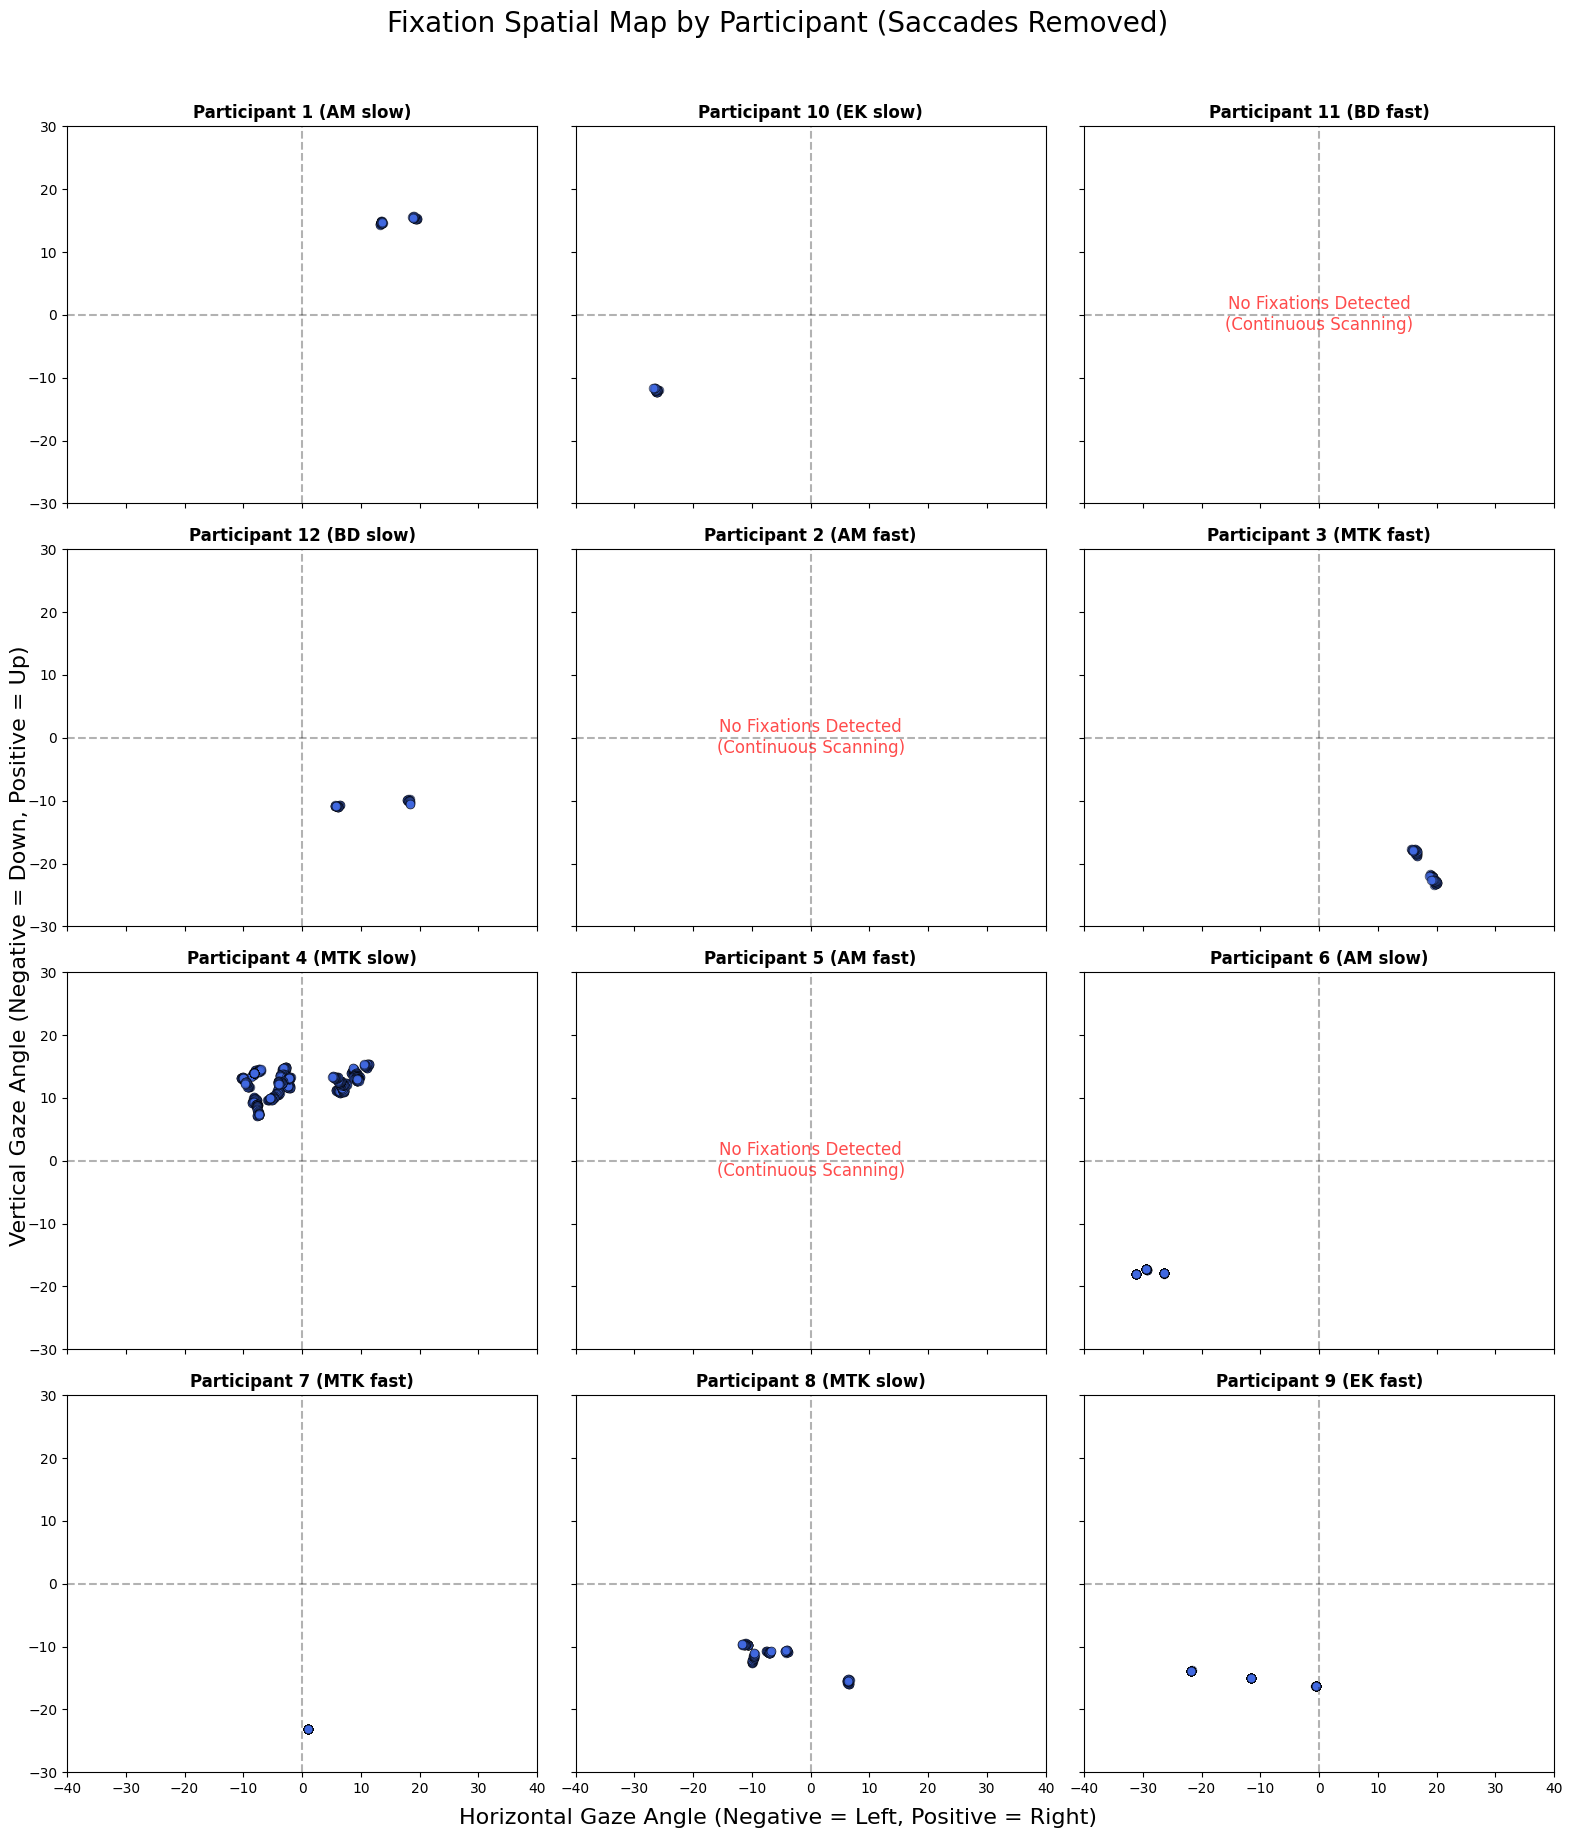

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get a sorted list of the unique participants
participants = master_df['Participant'].unique()

# 2. Create a 4x3 grid of subplots
fig, axes = plt.subplots(4, 3, figsize=(16, 18), sharex=True, sharey=True)
axes = axes.flatten()

for i, p in enumerate(participants):
    ax = axes[i]
    
    # Filter data for this specific participant
    p_data = master_df[master_df['Participant'] == p]
    
    # Extract condition for the title
    condition = f"{p_data['Clean_Type'].iloc[0]} {p_data['Speed'].iloc[0]}"
    
    # 3. Filter down to ONLY Fixations
    fixations = p_data[p_data['Gaze type'] == 'Fixation']
    
    # 4. Plot the fixations as distinct dots
    if not fixations.empty:
        ax.scatter(
            fixations['Horizontal gaze angle'], 
            fixations['Vertical gaze angle'], 
            color='royalblue',   # Changed to blue for clear visibility
            s=40,                # Made the dots slightly larger
            alpha=0.6,           # Slight transparency to show overlapping fixations
            edgecolor='black',   # Adds a clean border to each dot
            linewidth=0.5,
            label='Fixation Point'
        )
    else:
        # If they had 0 fixations (like AM fast), put a text note in the middle of their graph
        ax.text(0, 0, 'No Fixations Detected\n(Continuous Scanning)', 
                ha='center', va='center', color='red', alpha=0.7, fontsize=12)
    
    # Add crosshairs to mark the center of the screen
    ax.axhline(0, color='black', linestyle='--', alpha=0.3)
    ax.axvline(0, color='black', linestyle='--', alpha=0.3)
    
    # Set titles and standard axis limits
    ax.set_title(f"{p} ({condition})", fontsize=12, fontweight='bold')
    
    # Set fixed limits so all 12 "screens" represent the exact same physical space
    ax.set_xlim(-40, 40)
    ax.set_ylim(-30, 30)

# 5. Add master labels for the entire figure
fig.supxlabel('Horizontal Gaze Angle (Negative = Left, Positive = Right)', fontsize=16)
fig.supylabel('Vertical Gaze Angle (Negative = Down, Positive = Up)', fontsize=16)
fig.suptitle('Fixation Spatial Map by Participant (Saccades Removed)', fontsize=20, y=1.02)

# Adjust spacing and display
plt.tight_layout()
plt.show()

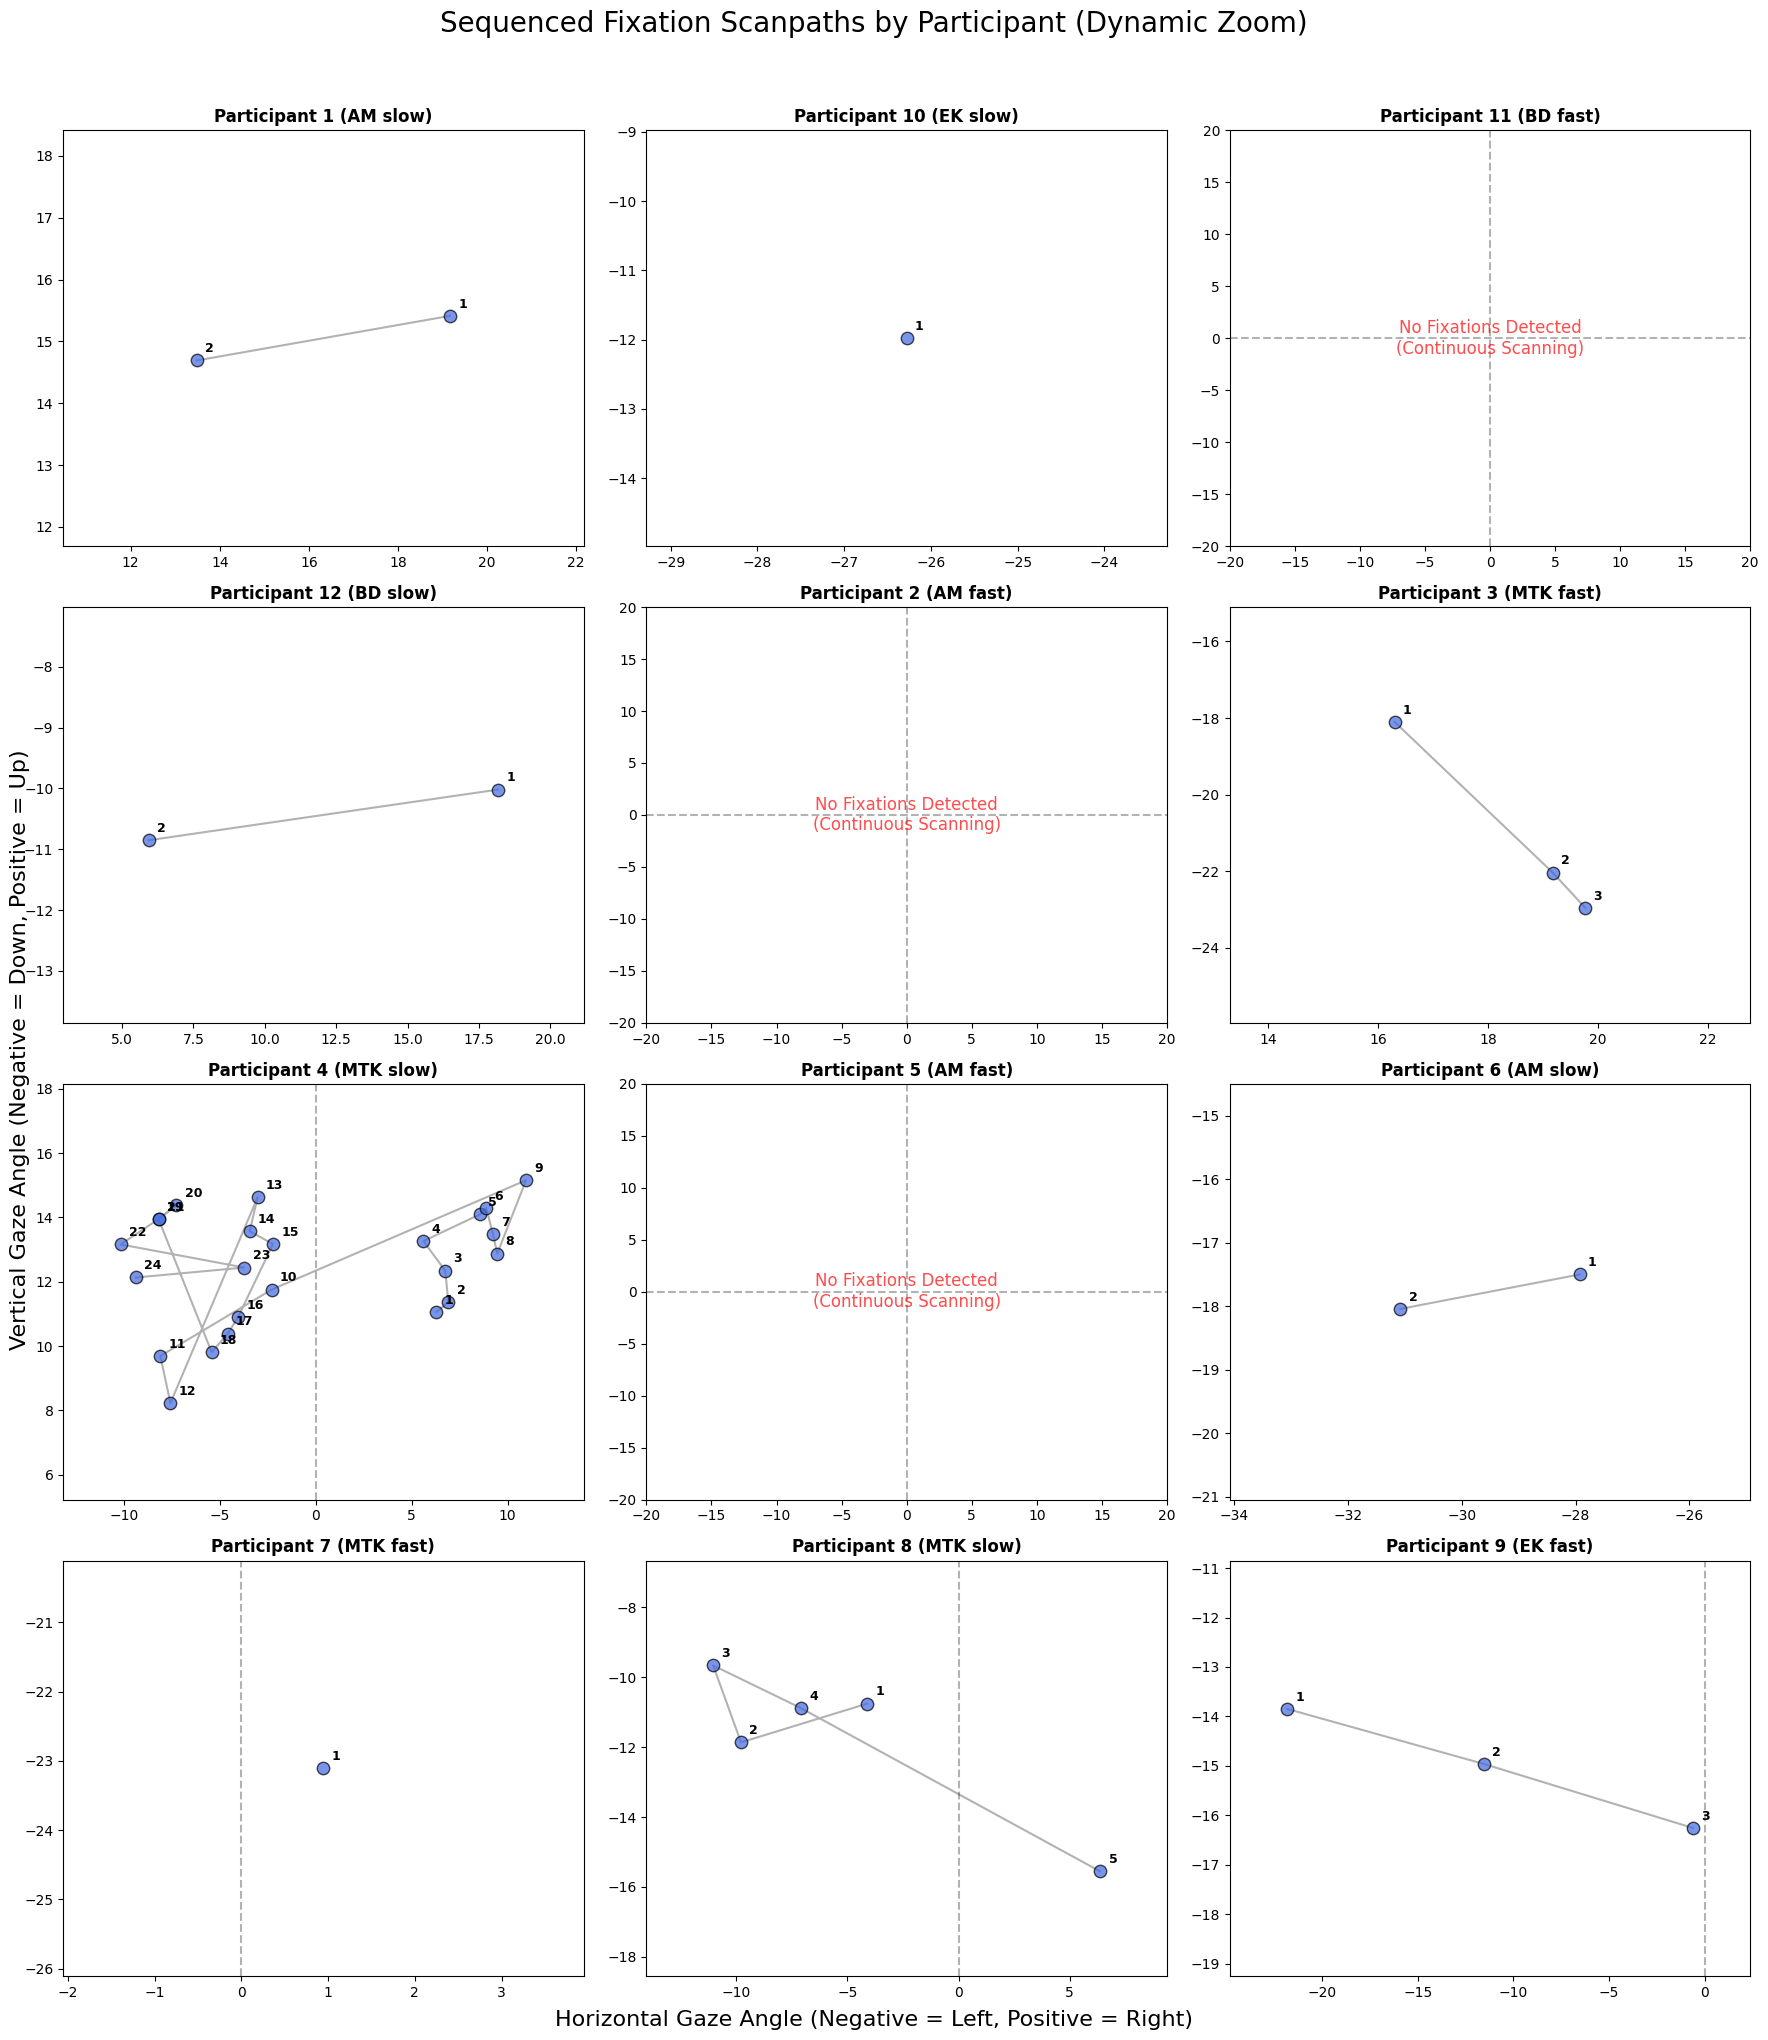

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get a sorted list of the unique participants
participants = master_df['Participant'].unique()

# 2. Create a 4x3 grid of subplots (Removed sharex and sharey)
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, p in enumerate(participants):
    ax = axes[i]
    
    # Filter data for this specific participant
    p_data = master_df[master_df['Participant'] == p]
    condition = f"{p_data['Clean_Type'].iloc[0]} {p_data['Speed'].iloc[0]}"
    
    # Filter down to ONLY Fixations
    fixations_raw = p_data[p_data['Gaze type'] == 'Fixation']
    
    if not fixations_raw.empty:
        # Calculate the Centroid (average position) for each distinct Fixation Event
        centroids = fixations_raw.groupby('Gaze_Event_ID').agg(
            Horizontal_Mean=('Horizontal gaze angle', 'mean'),
            Vertical_Mean=('Vertical gaze angle', 'mean'),
            Start_Time=('Time_Seconds', 'min')
        ).sort_values('Start_Time').reset_index()
        
        # Draw the lines connecting the fixations
        ax.plot(
            centroids['Horizontal_Mean'], 
            centroids['Vertical_Mean'], 
            color='gray', 
            linestyle='-', 
            linewidth=1.5, 
            alpha=0.6,
            zorder=1,
            label='Path'
        )
        
        # Draw the actual fixation dots
        ax.scatter(
            centroids['Horizontal_Mean'], 
            centroids['Vertical_Mean'], 
            color='royalblue',   
            s=80,                
            alpha=0.7,           
            edgecolor='black',   
            zorder=2,
            label='Fixation'
        )
        
        # Annotate each dot with its sequence number
        for idx, row in centroids.iterrows():
            ax.annotate(
                str(idx + 1), 
                (row['Horizontal_Mean'], row['Vertical_Mean']),
                textcoords="offset points", 
                xytext=(6, 6), 
                ha='left', 
                fontsize=9,
                fontweight='bold',
                color='black',
                zorder=3
            )
            
        # --- DYNAMIC ZOOM LOGIC ---
        # Find the min and max coordinates for this specific participant
        x_min, x_max = centroids['Horizontal_Mean'].min(), centroids['Horizontal_Mean'].max()
        y_min, y_max = centroids['Vertical_Mean'].min(), centroids['Vertical_Mean'].max()
        
        # Add a 3-degree padding so the dots don't touch the very edges of the graph
        # (Also handles the edge case where a user only has 1 fixation)
        padding = 3
        ax.set_xlim(x_min - padding, x_max + padding)
        ax.set_ylim(y_min - padding, y_max + padding)
            
    else:
        # Note for participants with 0 fixations
        # Placed using relative axes coordinates (0.5, 0.5 is the exact center) so it won't get lost
        ax.text(0.5, 0.5, 'No Fixations Detected\n(Continuous Scanning)', 
                ha='center', va='center', color='red', alpha=0.7, fontsize=12,
                transform=ax.transAxes) 
        
        # Set a default zoom for the empty plots just so they look normal
        ax.set_xlim(-20, 20)
        ax.set_ylim(-20, 20)
    
    # Add crosshairs to mark the center of the screen
    # (These will naturally disappear off-screen if the participant was looking far away)
    ax.axhline(0, color='black', linestyle='--', alpha=0.3)
    ax.axvline(0, color='black', linestyle='--', alpha=0.3)
    
    # Set titles
    ax.set_title(f"{p} ({condition})", fontsize=12, fontweight='bold')

# Add master labels for the entire figure
fig.supxlabel('Horizontal Gaze Angle (Negative = Left, Positive = Right)', fontsize=16)
fig.supylabel('Vertical Gaze Angle (Negative = Down, Positive = Up)', fontsize=16)
fig.suptitle('Sequenced Fixation Scanpaths by Participant (Dynamic Zoom)', fontsize=20, y=1.02)

# Adjust spacing and display
plt.tight_layout()
plt.show()